In [45]:
from strategy import *
from astropy.coordinates import ICRS
P = load_params('params_strategy.par')
import numpy as np
import matplotlib.pyplot as plt
from astropy.time import Time, TimeDelta
from astropy.coordinates import EarthLocation
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
from astropy.coordinates import EarthLocation, SkyCoord, AltAz
from astropy.time import Time
import astropy.units as u

#The coordinates of the field
ra = 53.11667
dec = -27.80833
#load the observer position
lat = -77.83
location = EarthLocation(lat=lat*u.deg, lon=0*u.deg, height=0*u.m) 

# Define the fixed sky center
source = SkyCoord(ra=ra*u.deg, dec=dec*u.deg, frame='icrs')  # RA ≈ 3h32m = 3.5411h

decr = np.radians(dec)  # DEC offset due to scanning [rad]
latr = np.radians(lat)             # Observer latitude [rad]
# Hour angle [rad]

#Load the scan duration and generate the time coordinates with the desired acquisition rate. 
dt = 2.7777777777777e-06*np.pi/3.14 #Make the timestep non rational to avoid some stripes in the hitmap.
T_duration = 1 #hours

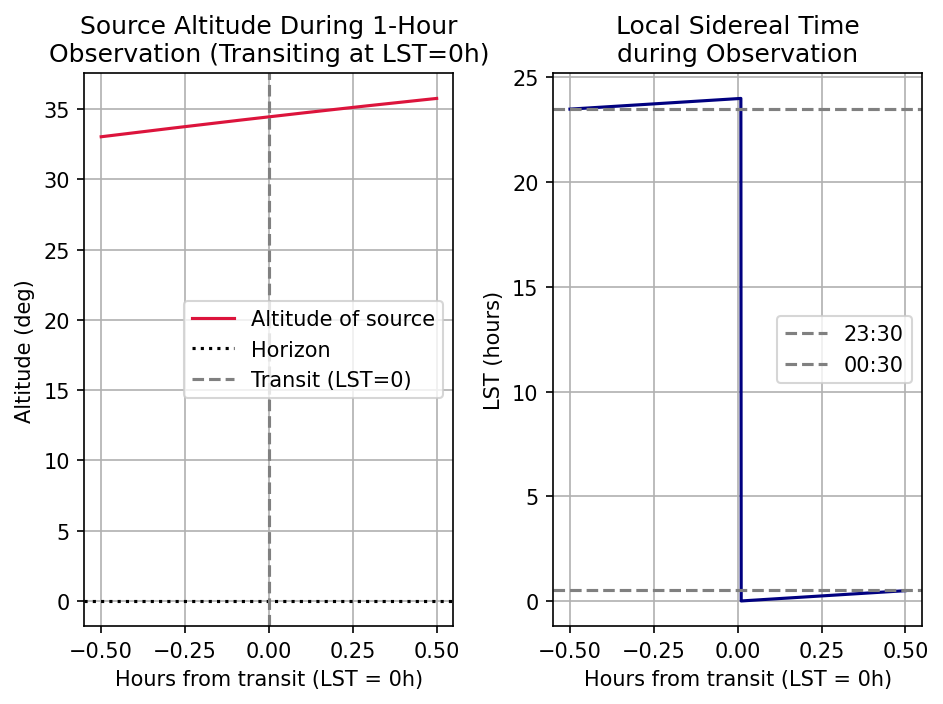

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Transit time (UTC): 2025-04-20 10:04:22.980 → LST = 00:00
LST at start: 23:29:17.82141501
LST at end  : 00:29:27.67807616


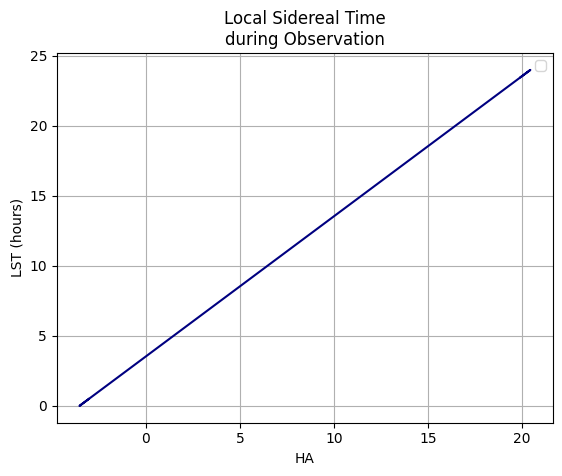

In [55]:
# So we find a time when LST = RA, and subtract RA to get LST=0h 
reference_time = Time("2025-04-20 00:00:00", scale="utc")
ra_hours = source.ra.to(u.hourangle).value  # ≈ 3.5411

# Find the UTC time when LST = RA
search_times = reference_time + np.linspace(0, 24, 10000) * u.hour
lst_array = search_times.sidereal_time('apparent', longitude=location.lon).hour
closest_idx = np.argmin(np.abs(lst_array - ra_hours))
time_zerolst = search_times[closest_idx]  # LST = RA

# Now shift back by RA hours → this puts LST = 0 at half the observing time
center_time = time_zerolst - ra_hours * u.hour  # LST=0 at source transit

# ---- Step 2: Create 1-hour observation window 
delta_hours = np.linspace(-T_duration/2, T_duration/2, 1000)
times = center_time + delta_hours * u.hour

# ---- Step 3: Compute AltAz and LST
altaz = source.transform_to(AltAz(obstime=times, location=location))
lst = times.sidereal_time('apparent', longitude=location.lon)

# ---- Plot Altitude vs Time ----
fig, axs = plt.subplots(1,2, dpi=150)
axs[0].plot(delta_hours, altaz.alt, label='Altitude of source', color='crimson')
axs[0].axhline(0, ls=':', color='black', label='Horizon')
axs[0].axvline(0, ls='--', color='gray', label='Transit (LST=0)')
axs[0].set_xlabel('Hours from transit (LST = 0h)')
axs[0].set_ylabel('Altitude (deg)')
#axs[0].set_ylim(32,37)
axs[0].set_title('Source Altitude During 1-Hour\nObservation (Transiting at LST=0h)')
axs[0].legend()
axs[0].grid(True)
# ---- Plot LST vs Time ----
axs[1].plot(delta_hours, lst.hour, color='navy')
axs[1].axhline(23.5, color='gray', linestyle='--', label='23:30')
axs[1].axhline(0.5, color='gray', linestyle='--', label='00:30')
axs[1].set_ylabel('LST (hours)')
axs[1].set_xlabel('Hours from transit (LST = 0h)')
axs[1].set_title('Local Sidereal Time\nduring Observation')
axs[1].grid(True)
axs[1].legend()
fig.tight_layout()
plt.show()

# ---- Print Transit Time and LST Range ----
print(f"Transit time (UTC): {center_time.iso} → LST = 00:00")
print(f"LST at start: {lst[0].to_string(unit=u.hour, sep=':', pad=True)}")
print(f"LST at end  : {lst[-1].to_string(unit=u.hour, sep=':', pad=True)}")

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


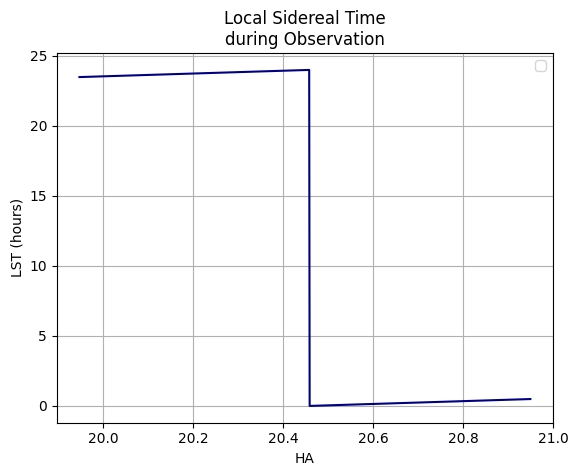

In [61]:
ra_hours = source.ra.to(u.hourangle).value  # Right Ascension in hours
# Calculate HA for each time
ha_hours = lst.hour - ra_hours  # LST - RA
ha_hours = (ha_hours + 24) % 24  # Ensures HA is between 0 and 24 hours

plt.plot(ha_hours, lst.hour, color='navy')
plt.ylabel('LST (hours)')
plt.xlabel('HA')
plt.title('Local Sidereal Time\nduring Observation')
plt.grid(True)
plt.legend()
fig.tight_layout()


In [ ]:
t_hours = (times - times[0]).to_value('hour')

#--------------------------------------------
T = np.arange(0, 1, dt) * 3600  # seconds
HA = np.arange(-1/2,1/2,dt) #hour
HAr = HA*np.pi/12
index, = np.where(HAr<0)
HAr[index] += 2*np.pi
HA = HAr*12/np.pi
#--------------------------------------------


fig, axs = plt.subplots(1,2, figsize=(10,4), dpi=100)
axs[0].plot(t_hours, lst.hour)
axs[0].plot(T/3600, HA, ':k')
axs[0].set_xlabel('UTC Time [hours]')
axs[0].set_ylabel('LST [hours]')
axs[0].set_title('LST over Observation')
axs[0].grid()

# Convert time_obs to offset from start in hours

# Now you can plot vs time in hours
axs[1].plot(t_hours, np.ones(len(t_hours)), c='r')
axs[1].plot(T/3600, np.ones(len(t_hours)), ':k')

axs[1].set_xlabel('Time [hours]')
axs[1].set_ylabel('Value')
axs[1].set_title('Time Evolution')
axs[1].grid(True)
plt.show()

In [15]:
T = np.arange(0, T_duration, dt) * 3600  # seconds

HA = np.arange(-T_duration/2,T_duration/2,dt) #hour
HAr = HA*np.pi/12
index, = np.where(HAr<0)
HAr[index] += 2*np.pi
HA = HAr*12/np.pi

# Guess initial start time
guess_time = Time('2025-04-17T23:30:00')

# Compute LST at midpoint of guess time
time_guess = guess_time + T * u.s
lst_guess = time_guess.sidereal_time('apparent', longitude=location.lon)
lst_mid = lst_guess[len(lst_guess)//2]

# Compute how much to shift so that LST = 0h at midpoint
delta_lst = lst_mid.wrap_at(24 * u.hourangle)

# Convert delta_lst to seconds (sidereal), then to UTC seconds
# 1 sidereal hour = 3600 * 0.9972695663 seconds ≈ 3597.87 sec
sidereal_hour_to_utc_sec = 3600 * 0.9972695663
delta_utc_sec = delta_lst.hour * sidereal_hour_to_utc_sec
delta_utc = TimeDelta(delta_utc_sec, format='sec')

# Adjust the start time
corrected_start_time = guess_time - delta_utc

# Final time array
time_obs = corrected_start_time + T * u.s

# Plot sidereal time vs time (in hours)
lst = time_obs.sidereal_time('apparent', longitude=location.lon)

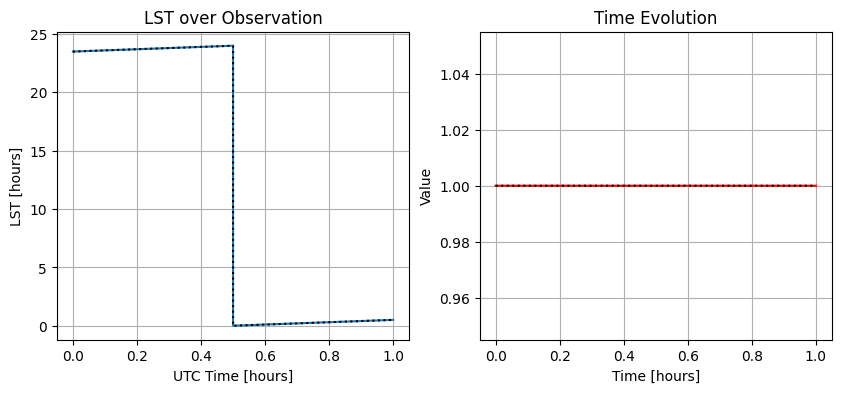

In [16]:
fig, axs = plt.subplots(1,2, figsize=(10,4), dpi=100)
axs[0].plot((time_obs - time_obs[0]).to_value(u.hour), lst.hour)
axs[0].plot(T/3600, HA, ':k')
axs[0].set_xlabel('UTC Time [hours]')
axs[0].set_ylabel('LST [hours]')
axs[0].set_title('LST over Observation')
axs[0].grid()

# Convert time_obs to offset from start in hours
t_hours = (time_obs - time_obs[0]).to_value('hour')

# Now you can plot vs time in hours
axs[1].plot(t_hours, np.ones(len(t_hours)), c='r')
axs[1].plot(T/3600, np.ones(len(t_hours)), ':k')

axs[1].set_xlabel('Time [hours]')
axs[1].set_ylabel('Value')
axs[1].set_title('Time Evolution')
axs[1].grid(True)
plt.show()

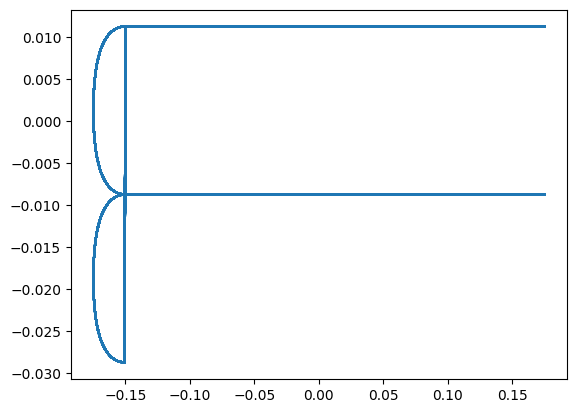

In [17]:
az, alt, flag = genLocalPath_cst_el_scan(az_size=0.3, alt_size=0.04, alt_step=0.02, acc=0.05, scan_v=0.05, dt=np.round(dt*3600,3))
scan_path, scan_flag = genScanPath(T, alt, az, flag)
plt.figure()
plt.plot(scan_path[:,0],scan_path[:,1] )

In [20]:
# Get the AltAz position of the fixed center at each time
altaz_center = sky_center.transform_to(AltAz(obstime=time_obs, location=location))
az_c = altaz_center.az.radian
alt_c = altaz_center.alt.radian

AttributeError: module 'numpy' has no attribute 'degreees'

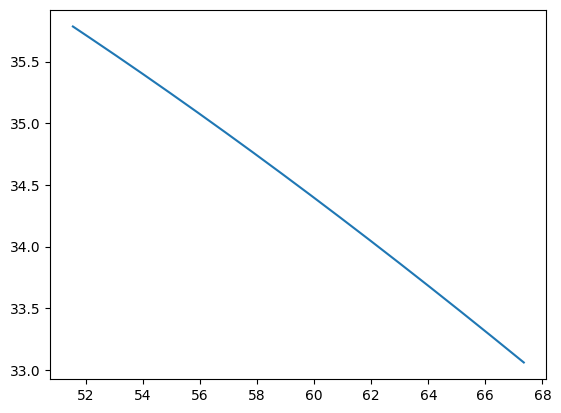

In [21]:
plt.plot(np.degrees(az_c),np.degrees(alt_c))

In [ ]:

# Constants
decr = np.radians(scan_path[:,1])  # DEC offset due to scanning [rad]
latr = np.radians(lat)             # Observer latitude [rad]
HAr = HA*np.pi/12

#Strategy formula
#-----------
za = np.arccos(np.sin(latr) * np.sin(decr) + np.cos(latr) * np.cos(decr) * np.cos(HAr))
alt = np.pi/2 - za
#alt += np.radians(scan_path[:,1])
sinAz = np.sin(HAr) * np.cos(decr) / np.sin(za)
cosAz = (np.sin(decr) - np.sin(latr) * np.cos(za))/(np.cos(latr) * np.sin(za))
azi = np.arctan2(sinAz,cosAz)
azi += np.radians(scan_path[:,0])  
azi[index] += 2*np.pi 
#-----------

#NAMAP formula
#-----------
el = np.arcsin(np.sin(decr)*np.sin(latr)+np.cos(latr)*np.cos(decr)*np.cos(HAr))
#el += np.radians(scan_path[:,1])
sin_az = -np.sin(HAr)*np.cos(latr) / np.cos(el)
cos_az = (np.sin(decr)-np.sin(latr)*np.sin(el))/(np.cos(latr)*np.cos(el))
az = np.arctan2(sin_az, cos_az)
az = np.arccos(cos_az)
az += np.radians(scan_path[:,0])  
az[index] = 2*np.pi - az[index]  
#-----------


for A,E,C,ls in zip((azi,az), (alt, el), ('k','cyan'), ('solid', '--')):
    AB = A.copy()
    AB[index]=AB[index]-2*np.pi
    plt.plot(np.degrees(AB),np.degrees(E), c=C, lw=1, ls=ls)
#plt.xlim(-10,10)
plt.tight_layout()
plt.figure()
plt.plot(np.degrees(azi - az), label="azi - az")
plt.plot(np.degrees(alt - el), label="alt - el")
plt.legend()
plt.xlabel("Sample")
plt.ylabel("Angle difference (deg)")


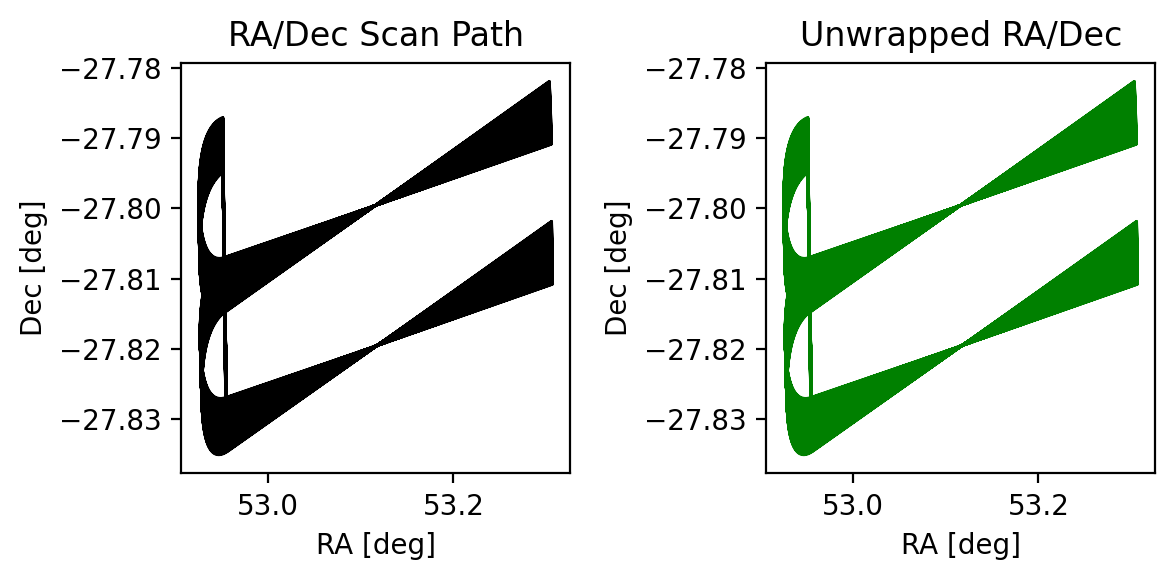

In [6]:


# Apply scan offsets to (az_c, alt_c)
# These are small-angle offsets in azimuth and altitude
az_total = az_c + np.radians(scan_path[:, 0])
alt_total = alt_c + np.radians(scan_path[:, 1])

# Now convert each (az_total, alt_total) back to RA/Dec
altaz = AltAz(az=az_total*u.rad, alt=alt_total*u.rad,
              obstime=time_obs, location=location)
from astropy.coordinates import ICRS
skycoord_icrs = altaz.transform_to(ICRS())
RA = skycoord_icrs.ra.radian
Dec = skycoord_icrs.dec.radian

# Build final path
path = np.vstack((np.degrees(RA), np.degrees(Dec))).T

# Plotting
fig, axs = plt.subplots(1,2,figsize=(6,3),dpi=200)
axs[0].plot(path[:,0], path[:,1], 'k', lw=1)
axs[0].set_title("RA/Dec Scan Path")
axs[0].set_xlabel("RA [deg]")
axs[0].set_ylabel("Dec [deg]")

RA_unwrapped = (RA + np.pi) % (2 * np.pi) - np.pi
axs[1].plot(np.degrees(RA_unwrapped), np.degrees(Dec), 'g', lw=1)
axs[1].set_title("Unwrapped RA/Dec")
axs[1].set_xlabel("RA [deg]")
axs[1].set_ylabel("Dec [deg]")
plt.tight_layout()
plt.show()


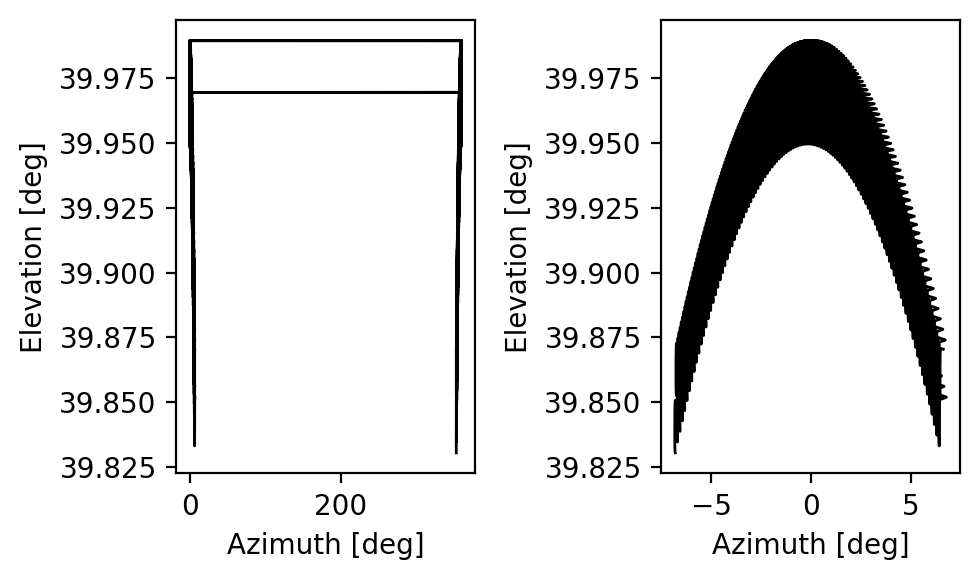

In [21]:
# Precompute trigonometric terms
sin_dec = np.sin(decr)
cos_dec = np.cos(decr)
sin_lat = np.sin(latr)
cos_lat = np.cos(latr)
cos_HA = np.cos(HAr)
sin_HA = np.sin(HAr)

# Elevation (altitude)
el = np.arcsin(sin_dec * sin_lat + cos_dec * cos_lat * cos_HA)

# Azimuth (from North, increasing towards East)
sin_az = sin_HA * cos_dec
cos_az = (sin_dec - sin_lat * np.sin(el)) / (cos_lat * np.cos(el))
az = np.arctan2(sin_az, cos_az)

# Normalize azimuth to [0, 2pi]
az = (az + 2 * np.pi) % (2 * np.pi)

# Apply scan offsets
az += np.radians(scan_path[:,0])
el += np.radians(scan_path[:,1])
# Wrap azimuth again if needed
az = (az + 2 * np.pi) % (2 * np.pi)

fig, axs = plt.subplots(1,2,figsize=(5,3),dpi=200)
axs[0].plot(np.degrees(az), np.degrees(el), c='k', lw=1, ls='-')
axs[0].set_xlabel("Azimuth [deg]")
axs[0].set_ylabel("Elevation [deg]")
# "Unwrap" from [0, 2π) to (-π, π]
az_unwrapped = (az + np.pi) % (2 * np.pi) - np.pi
ped = (az + np.pi) % (2 * np.pi) - np.pi
axs[1].plot(np.degrees(az_unwrapped), np.degrees(el), c='k', lw=1, ls='-')
axs[1].set_xlabel("Azimuth [deg]")
axs[1].set_ylabel("Elevation [deg]")
plt.tight_layout()


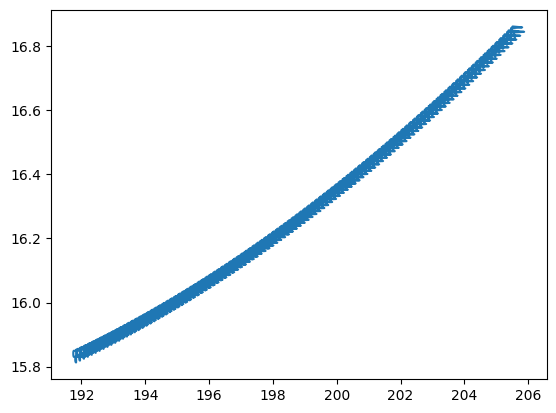

In [24]:
# Get the AltAz position of the fixed center at each time
altaz_center = sky_center.transform_to(AltAz(obstime=time_obs, location=location))
az_c = altaz_center.az.radian
alt_c = altaz_center.alt.radian

# Apply scan offsets to (az_c, alt_c)
# These are small-angle offsets in azimuth and altitude
az_total = az_c + np.radians(scan_path[:, 0])
alt_total = alt_c + np.radians(scan_path[:, 1])

13.82858193715249


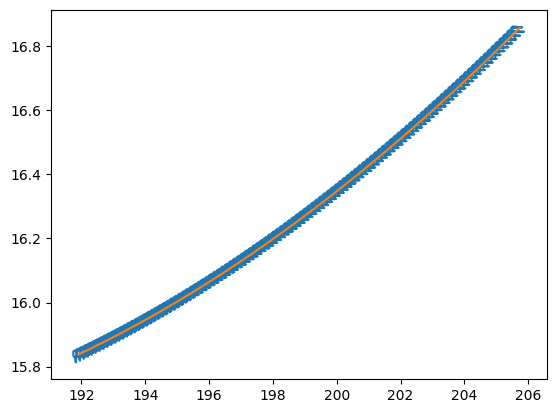

In [30]:
plt.plot(np.degrees(az_total), np.degrees(alt_total))
plt.plot(np.degrees(az_c), np.degrees(alt_c))
print(np.degrees(az_c.max()-az_c.min()))



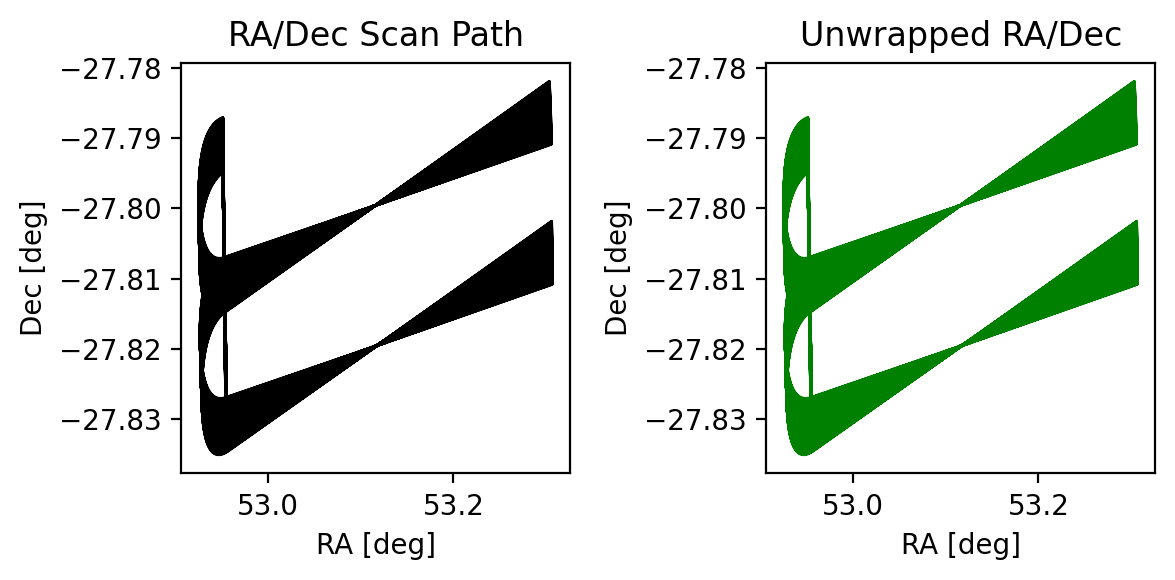

In [23]:
# Now convert each (az_total, alt_total) back to RA/Dec
altaz = AltAz(az=az_total*u.rad, alt=alt_total*u.rad,
              obstime=time_obs, location=location)
skycoord_icrs = altaz.transform_to(ICRS())
RA = skycoord_icrs.ra.radian
Dec = skycoord_icrs.dec.radian

# Build final path
path = np.vstack((np.degrees(RA), np.degrees(Dec))).T

# Plotting
fig, axs = plt.subplots(1,2,figsize=(6,3),dpi=200)
axs[0].plot(path[:,0], path[:,1], 'k', lw=1)
axs[0].set_title("RA/Dec Scan Path")
axs[0].set_xlabel("RA [deg]")
axs[0].set_ylabel("Dec [deg]")

RA_unwrapped = (RA + np.pi) % (2 * np.pi) - np.pi
axs[1].plot(np.degrees(RA_unwrapped), np.degrees(Dec), 'g', lw=1)
axs[1].set_title("Unwrapped RA/Dec")
axs[1].set_xlabel("RA [deg]")
axs[1].set_ylabel("Dec [deg]")
plt.tight_layout()
plt.show()